#PROJECT FOR BIG DATA ANALYSIS - Makulbek Alisher , Muhamedali Nurislam , Rashid

#TASK 1 — Data Loading & Cleaning

### 1.1 task import

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.metrics import roc_curve

### data load

In [4]:
transactions = pd.read_excel("ecom_transactions.xlsx")
clients = pd.read_excel("ecom_clients.xlsx")

 Check data structure

In [5]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10486 entries, 0 to 10485
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10486 non-null  object        
 1   zip_code          10174 non-null  float64       
 2   country_code      10486 non-null  object        
 3   state_name        10486 non-null  object        
 4   city_name         10486 non-null  object        
 5   delivery_type     10173 non-null  object        
 6   sales_zone        10486 non-null  object        
 7   client_segment    10486 non-null  object        
 8   client_id         10486 non-null  object        
 9   order_ts          10486 non-null  datetime64[ns]
 10  dispatch_ts       10276 non-null  datetime64[ns]
 11  item_id           10486 non-null  object        
 12  item_description  10486 non-null  object        
 13  units_count       10486 non-null  int64         
 14  total_sum         1017

In [6]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 1495 non-null   object 
 1   Age                       1495 non-null   int64  
 2   Attrition                 1495 non-null   object 
 3   BusinessTravel            1495 non-null   object 
 4   DailyRate                 1495 non-null   int64  
 5   Department                1495 non-null   object 
 6   DistanceFromHome          1377 non-null   float64
 7   Education                 1376 non-null   float64
 8   EducationField            1495 non-null   object 
 9   EmployeeCount             1495 non-null   int64  
 10  EmployeeNumber            1495 non-null   int64  
 11  EnvironmentSatisfaction   1495 non-null   int64  
 12  Gender                    1495 non-null   object 
 13  HourlyRate                1495 non-null   int64  
 14  JobInvol

In [7]:
transactions.head()

,transaction_id,zip_code,country_code,state_name,city_name,delivery_type,sales_zone,client_segment,client_id,order_ts,dispatch_ts,item_id,item_description,units_count,total_sum,profit,discount
0,T01936,85023.0,USA,Arizona,Phoenix,Standard Class,West,Consumer,C0568,2021-07-17,2021-07-22,P00856,"Furniture_Tables_Chromcraft 48"" x 96"" Racetrac...",5,801.600,-448.8960,0.5
1,T00178,98198.0,USA,Washington,Des Moines,Second Class,West,Consumer,C1308,2018-09-19,2018-09-21,P00349,Technology_Phones_Nortel Meridian M3904 Profes...,2,246.384,27.7182,0.2
2,T04512,NaN,USA,Illinois,Quincy,Standard Class,Central,Consumer,C0475,2019-09-30,2019-10-04,P01391,Office Supplies_Binders_Accohide Poly Flexible...,4,2.992,-4.4880,0.8
3,T01059,78041.0,USA,Texas,Laredo,Standard Class,Central,Consumer,C0445,2020-10-12,2020-10-18,P00584,"Furniture_Furnishings_Tenex ""The Solids"" Textu...",5,139.920,-150.4140,0.6
4,T04032,92037.0,USA,California,San Diego,Standard Class,West,CONSUMER,C0462,2020-02-04,2020-02-09,P00608,Office Supplies_Labels_Avery 508,3,14.730,7.2177,0.0


In [8]:
clients.head()

,client_id,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,C0395,43,No,Travel_Frequently,313,Research & Development,21.0,3.0,Medical,1,...,1,80,1,8,1,3,3,2,1,2
1,C0840,35,No,Travel_Rarely,982,Research & Development,1.0,4.0,Medical,1,...,2,80,1,10,2,3,8,0,1,7
2,C1230,24,No,Travel_Rarely,506,Research & Development,29.0,1.0,Medical,1,...,2,80,3,6,2,4,6,2,1,2
3,C0507,29,No,Travel_Rarely,1176,Sales,3.0,2.0,Medical,1,...,1,80,1,6,5,2,6,0,1,2
4,C0853,19,No,Travel_Rarely,645,Research & Development,9.0,2.0,Life Sciences,1,...,3,80,0,1,4,3,1,1,0,0


###1.2 Identify and handle missing values

In [9]:
transactions.isna().sum()

,0
transaction_id,0
zip_code,312
country_code,0
state_name,0
city_name,0
delivery_type,313
sales_zone,0
client_segment,0
client_id,0
order_ts,0


In [10]:
clients.isna().sum()

,0
client_id,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,118
Education,119
EducationField,0
EmployeeCount,0


###Handle NaN values


In [11]:
# --- Transactions ---
# Numerical → median
num_cols_tr = transactions.select_dtypes(include=np.number).columns
transactions[num_cols_tr] = transactions[num_cols_tr].fillna(
    transactions[num_cols_tr].median()
)

# Categorical → mode
cat_cols_tr = transactions.select_dtypes(include="object").columns
transactions[cat_cols_tr] = transactions[cat_cols_tr].apply(
    lambda x: x.fillna(x.mode()[0])
)

# --- Clients ---
num_cols_cl = clients.select_dtypes(include=np.number).columns
clients[num_cols_cl] = clients[num_cols_cl].fillna(
    clients[num_cols_cl].median()
)

cat_cols_cl = clients.select_dtypes(include="object").columns
clients[cat_cols_cl] = clients[cat_cols_cl].apply(
    lambda x: x.fillna(x.mode()[0])
)


In [12]:
transactions.isna().sum()
clients.isna().sum()

,0
client_id,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


###1.3 Detect and treat outliers using at least one statistical or visualization-based method.

####We use IQR because it works well with uneven business data

In [13]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[column] < lower) | (df[column] > upper)).sum()
    df[column] = df[column].clip(lower, upper)

    return df, outliers


###before delete outliers

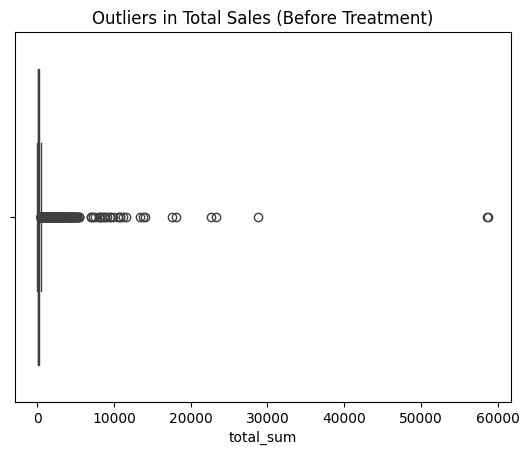

In [14]:
sns.boxplot(x=transactions["total_sum"])
plt.title("Outliers in Total Sales (Before Treatment)")
plt.show()


In [15]:
for col in ["total_sum", "profit", "units_count"]:
    transactions, n_outliers = cap_outliers_iqr(transactions, col)
    print(f"{col}: capped {n_outliers} outliers")

total_sum: capped 1255 outliers
profit: capped 2105 outliers
units_count: capped 174 outliers


####visual

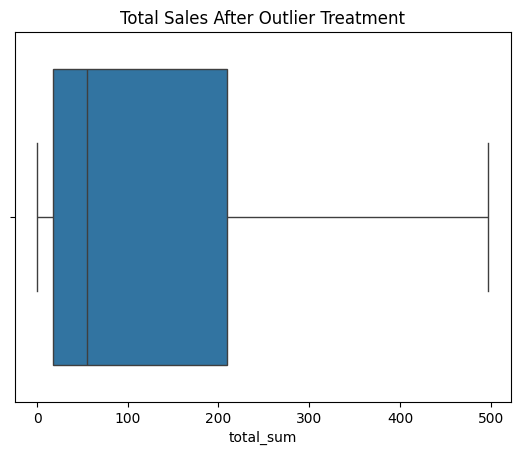

In [16]:
sns.boxplot(x=transactions["total_sum"])
plt.title("Total Sales After Outlier Treatment")
plt.show()

###1.4 Normalize inconsistent categorical variables.

In [17]:
# Standardize text format
cat_fix_cols = [
    "country_code", "state_name", "city_name",
    "delivery_type", "sales_zone", "client_segment"
]

for col in cat_fix_cols:
    transactions[col] = (
        transactions[col]
        .str.strip()
        .str.lower()
        .str.title()
    )

clients["Gender"] = clients["Gender"].str.strip().str.title()
clients["MaritalStatus"] = clients["MaritalStatus"].str.strip().str.title()

###1.5.Fix incorrect data types and remove or resolve duplicates.

In [18]:
# Convert dates
transactions["order_ts"] = pd.to_datetime(transactions["order_ts"])
transactions["dispatch_ts"] = pd.to_datetime(transactions["dispatch_ts"])

# Remove duplicates
dup_tr = transactions.duplicated().sum()
dup_cl = clients.duplicated().sum()

transactions.drop_duplicates(inplace=True)
clients.drop_duplicates(inplace=True)

print("Removed transaction duplicates:", dup_tr)
print("Removed client duplicates:", dup_cl)

Removed transaction duplicates: 0
Removed client duplicates: 15


###1.6.Identify and correct logical errors in the data.

In [19]:
# Dispatch before order → fix by swapping
mask = transactions["dispatch_ts"] < transactions["order_ts"]
transactions.loc[mask, ["order_ts", "dispatch_ts"]] = \
transactions.loc[mask, ["dispatch_ts", "order_ts"]].values

# Profit should not be negative
transactions = transactions[transactions["profit"] >= 0]

# Discount must be between 0 and 1
transactions = transactions[
    (transactions["discount"] >= 0) &
    (transactions["discount"] <= 1)
]

###1.7.Produce clean datasets suitable for analysis.

In [20]:
print("Clean transactions shape:", transactions.shape)
print("Clean clients shape:", clients.shape)

Clean transactions shape: (8413, 17)
Clean clients shape: (1480, 36)


In [21]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8413 entries, 1 to 10485
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    8413 non-null   object        
 1   zip_code          8413 non-null   float64       
 2   country_code      8413 non-null   object        
 3   state_name        8413 non-null   object        
 4   city_name         8413 non-null   object        
 5   delivery_type     8413 non-null   object        
 6   sales_zone        8413 non-null   object        
 7   client_segment    8413 non-null   object        
 8   client_id         8413 non-null   object        
 9   order_ts          8413 non-null   datetime64[ns]
 10  dispatch_ts       8238 non-null   datetime64[ns]
 11  item_id           8413 non-null   object        
 12  item_description  8413 non-null   object        
 13  units_count       8413 non-null   float64       
 14  total_sum         8413 non-n

In [22]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1480 entries, 0 to 1494
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   Attrition                 1480 non-null   object 
 3   BusinessTravel            1480 non-null   object 
 4   DailyRate                 1480 non-null   int64  
 5   Department                1480 non-null   object 
 6   DistanceFromHome          1480 non-null   float64
 7   Education                 1480 non-null   float64
 8   EducationField            1480 non-null   object 
 9   EmployeeCount             1480 non-null   int64  
 10  EmployeeNumber            1480 non-null   int64  
 11  EnvironmentSatisfaction   1480 non-null   int64  
 12  Gender                    1480 non-null   object 
 13  HourlyRate                1480 non-null   int64  
 14  JobInvolvemen

#Task 2. Exploratory Data Analysis & Visualization

###2.1 Descriptive statistics

In [23]:
# Basic descriptive statistics
transactions[["total_sum", "profit", "units_count"]].describe()

,total_sum,profit,units_count
count,8413.000000,8413.000000,8413.000000
mean,135.889726,23.368007,3.714073
std,165.713042,23.397718,2.151160
min,0.990000,0.000000,-1.000000
25%,18.540000,5.433600,2.000000
50%,55.500000,12.096000,3.000000
75%,194.320000,37.797000,5.000000
max,497.351250,66.686062,9.500000


In [24]:
transactions[["total_sum", "profit"]].median()
transactions[["total_sum", "profit"]].quantile([0.25, 0.5, 0.75])

,total_sum,profit
0.25,18.54,5.4336
0.50,55.50,12.0960
0.75,194.32,37.7970


###1.2 Visual

###Histogram of total sales

####visual 1

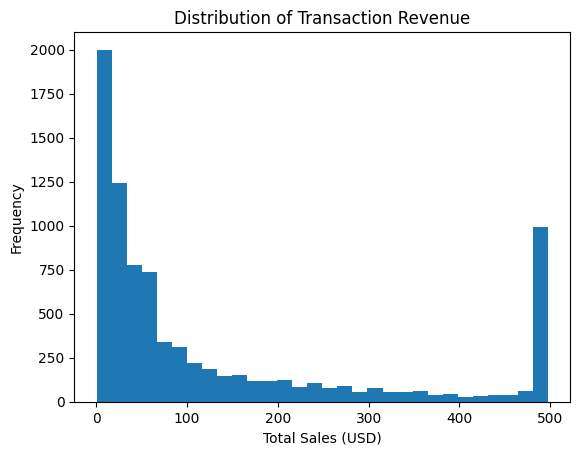

In [25]:
plt.figure()
plt.hist(transactions["total_sum"], bins=30)
plt.title("Distribution of Transaction Revenue")
plt.xlabel("Total Sales (USD)")
plt.ylabel("Frequency")
plt.show()

#####The distribution shows that most transactions have low to medium revenue, while high-value purchases are relatively rare.

####visual 2

####Profit distribution

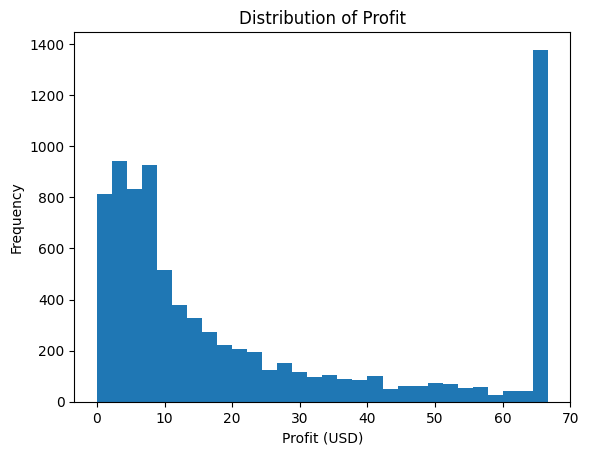

In [26]:
plt.figure()
plt.hist(transactions["profit"], bins=30)
plt.title("Distribution of Profit")
plt.xlabel("Profit (USD)")
plt.ylabel("Frequency")
plt.show()

####Profit values are right-skewed, indicating that a small number of transactions generate high profits.

In [27]:
transactions["order_month"] = transactions["order_ts"].dt.to_period("M").dt.to_timestamp()

monthly_sales = transactions.groupby("order_month")["total_sum"].sum()

# remove unrealistic years
monthly_sales = monthly_sales[
    (monthly_sales.index.year >= 2015) &
    (monthly_sales.index.year <= 2025)
]

###time-based trend

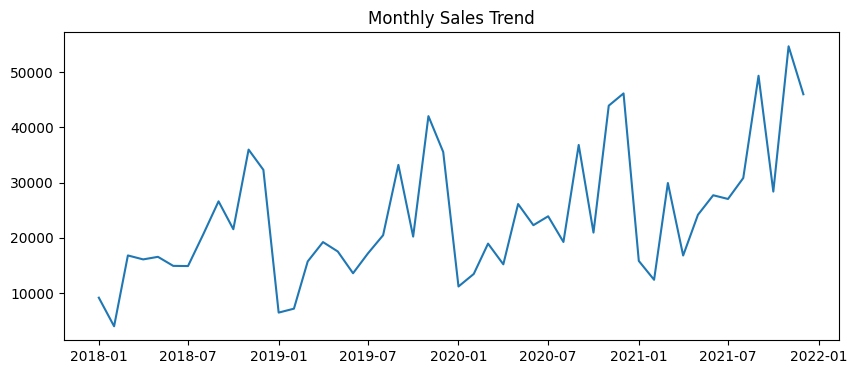

In [28]:
plt.figure(figsize=(10,4))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.show()

###Customer segments

Average sales per segment

In [29]:
segment_sales = transactions.groupby("client_segment")["total_sum"].mean()
segment_sales

,total_sum
client_segment,
Consumer,134.211281
Corporate,139.341361
Home Office,159.635773
Home Office,134.342827


####visual 3

Bar chart

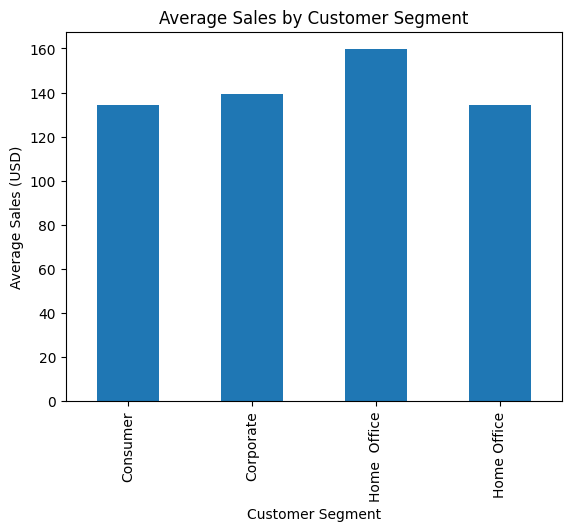

In [30]:
plt.figure()
segment_sales.plot(kind="bar")
plt.title("Average Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Sales (USD)")
plt.show()

####visual 4

Delivery type comparison (extra safe)

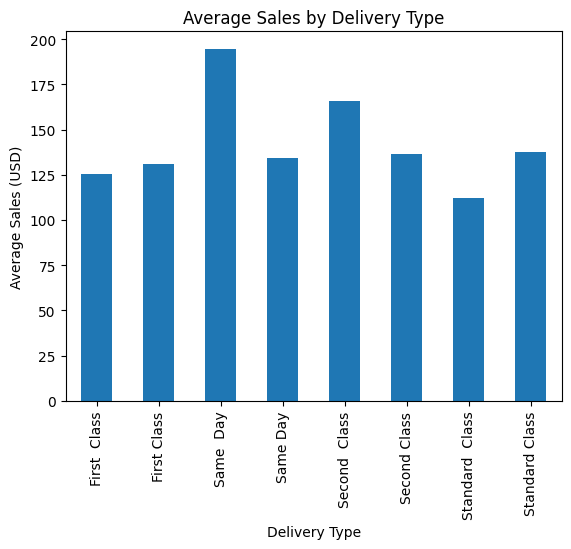

In [31]:
delivery_sales = transactions.groupby("delivery_type")["total_sum"].mean()

plt.figure()
delivery_sales.plot(kind="bar")
plt.title("Average Sales by Delivery Type")
plt.xlabel("Delivery Type")
plt.ylabel("Average Sales (USD)")
plt.show()

#Task 3 TIME SERIES ANALYSIS & FORECASTING

## 3.1Aggregate data

In [32]:
# Use order date
transactions["order_date"] = transactions["order_ts"].dt.to_period("M")

# Monthly sales
monthly_sales = transactions.groupby("order_date")["total_sum"].sum()

# Convert index to datetime
monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.head()

,total_sum
order_date,
1708-09-01,4167.281694
2018-01-01,9150.255195
2018-02-01,3969.055945
2018-03-01,16802.556193
2018-04-01,16086.540104


##Plot time series

In [33]:
# keep only realistic years
monthly_sales = monthly_sales[
    (monthly_sales.index.year >= 2010) &
    (monthly_sales.index.year <= 2025)
]

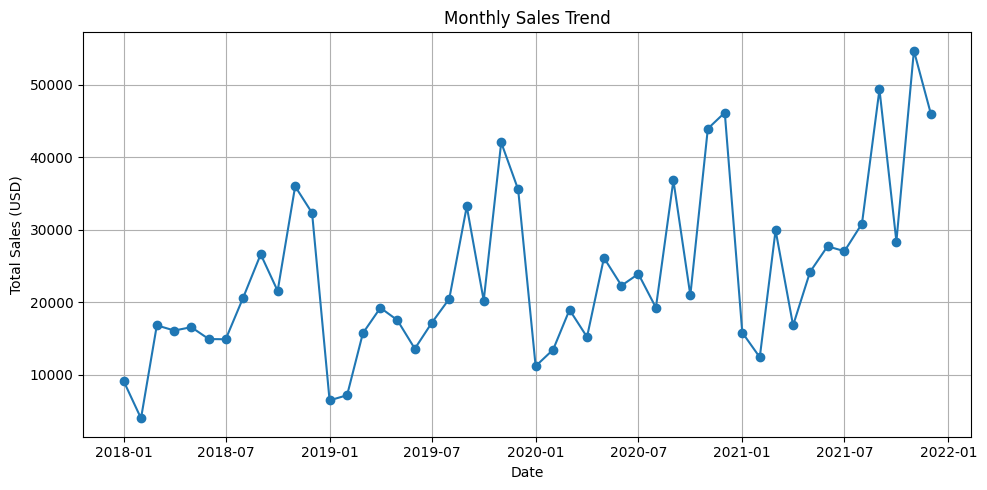

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

###This helps visually inspect trend and seasonality.

###task 3.2

###Stationarity test (ADF Test)

In [35]:
adf_result = adfuller(monthly_sales)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.0655632509776565
p-value: 0.0011035520964157732


#make starionarity

In [36]:
monthly_sales_diff = monthly_sales.diff().dropna()

In [37]:
# ADF test again
adf_diff = adfuller(monthly_sales_diff)
print("ADF p-value after differencing:", adf_diff[1])

ADF p-value after differencing: 6.888737219438606e-25


###3.3.Plot ACF and PACF.

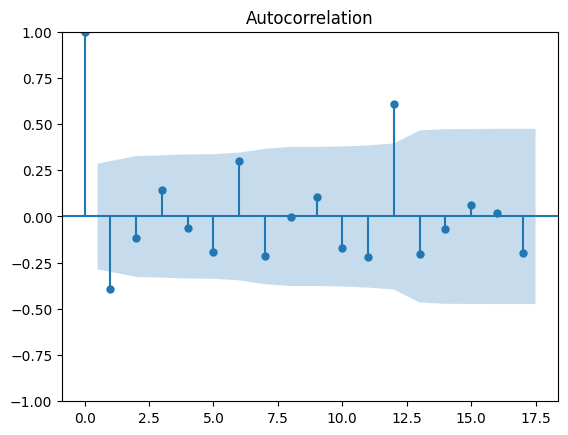

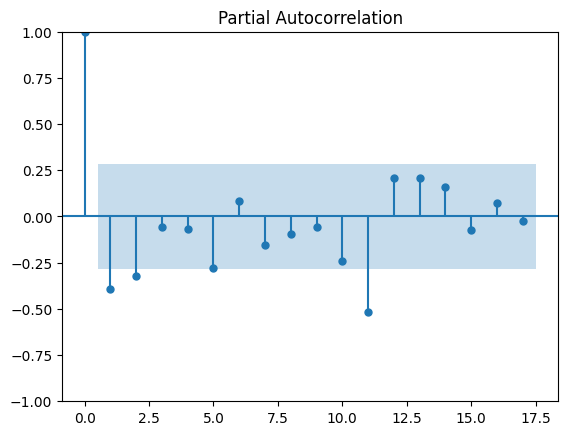

In [38]:
plot_acf(monthly_sales_diff)
plt.show()

plot_pacf(monthly_sales_diff)
plt.show()

#3.4.Fit at least one ARIMA or SARIMA model.

In [39]:
# make sure order_ts is datetime
transactions["order_ts"] = pd.to_datetime(transactions["order_ts"], errors="coerce")

# monthly aggregation
transactions["order_month"] = transactions["order_ts"].dt.to_period("M").dt.to_timestamp()
monthly_sales = transactions.groupby("order_month")["total_sum"].sum()

monthly_sales.head()

,total_sum
order_month,
1708-09-01,4167.281694
2018-01-01,9150.255195
2018-02-01,3969.055945
2018-03-01,16802.556193
2018-04-01,16086.540104


In [40]:
# keep only realistic years
monthly_sales = monthly_sales[
    (monthly_sales.index.year >= 2010) &
    (monthly_sales.index.year <= 2025)
]

In [41]:
# split data: last 12 months for testing
train = monthly_sales[:-12]
test = monthly_sales[-12:]

# fit ARIMA model
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

model_fit.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              total_sum   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -371.459
Date:                Thu, 25 Dec 2025   AIC                            748.917
Time:                        17:43:49   BIC                            753.583
Sample:                    01-01-2018   HQIC                           750.528
                         - 12-01-2020                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3528      0.401      0.880      0.379      -0.433       1.139
ma.L1         -0.8102      0.210     -3.866      0.000      -1.221      -0.399
sigma2      1.061e+08    2.1e-09   5.05e+16      0.000    1.06e+08    1.06e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.20   Jarque-Bera (JB):                 0.39
Prob(Q):                              0.66   Prob(JB):                         0.82
Heteroskedasticity (H):               1.34   Skew:                            -0.16
Prob(H) (two-sided):                  0.62   Kurtosis:                         3.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.97e+32. Standard errors may be unstable.
"""

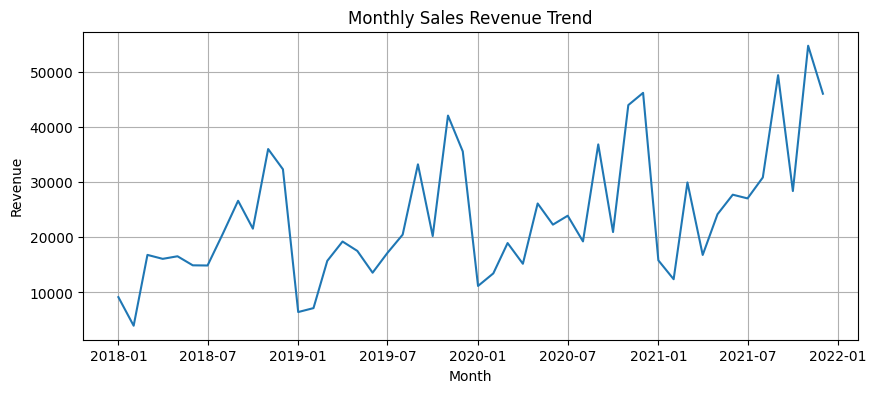

In [42]:
plt.figure(figsize=(10,4))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

###3.5.Forecast the next 12 periods.


In [43]:
# forecast next 12 months
forecast = model_fit.forecast(steps=12)

forecast

,predicted_mean
2021-01-01,37639.346942
2021-02-01,34632.110527
2021-03-01,33571.017135
2021-04-01,33196.613851
2021-05-01,33064.506895
2021-06-01,33017.893393
2021-07-01,33001.445974
2021-08-01,32995.642556
2021-09-01,32993.594840
2021-10-01,32992.872310


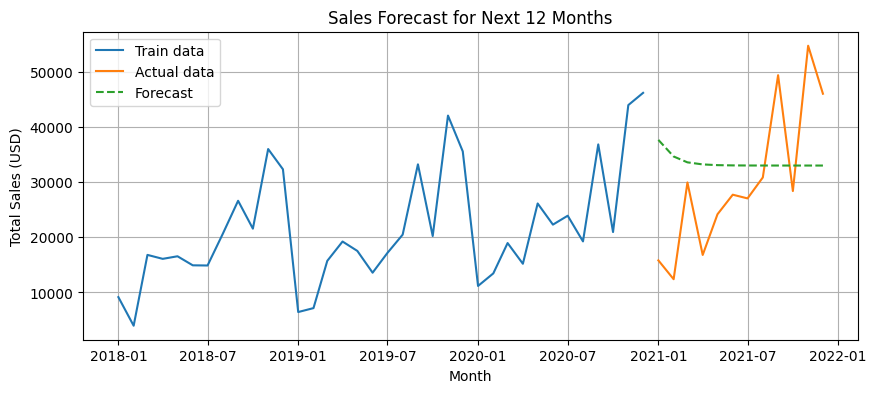

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(train.index, train.values, label="Train data")
plt.plot(test.index, test.values, label="Actual data")
plt.plot(forecast.index, forecast.values, label="Forecast", linestyle="--")
plt.title("Sales Forecast for Next 12 Months")
plt.xlabel("Month")
plt.ylabel("Total Sales (USD)")
plt.legend()
plt.grid(True)
plt.show()

###3.6.Evaluate forecast accuracy using RMSE and MAE.

In [45]:
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 13936.903144720069
MAE: 11846.018643756504


#Task 4. Unsupervised Learning: Customer Segmentation

###4.1.Select and preprocess relevant numerical and categorical features.

####I select numerical features that describe customer value and activity, and categorical features that describe customer type.

In [46]:
# aggregate transactions to customer level
customer_agg = transactions.groupby("client_id").agg(
    total_spent=("total_sum", "sum"),
    total_orders=("transaction_id", "count"),
    total_items=("units_count", "sum")
).reset_index()

# merge with client data
customers = clients.merge(customer_agg, on="client_id", how="left")

# customers without purchases get zeros
customers[["total_spent", "total_orders", "total_items"]] = (
    customers[["total_spent", "total_orders", "total_items"]].fillna(0)
)

####Numerical variables represent spending and demographics, categorical variables represent customer characteristics.

In [47]:
num_features = [
    "Age",
    "MonthlyIncome",
    "total_spent",
    "total_orders",
    "total_items"
]

cat_features = [
    "Gender",
    "MaritalStatus",
    "Department"
]

X_num = customers[num_features]
X_cat = customers[cat_features]

###4.2.Encode categorical variables appropriately.

####Categorical variables are converted into numerical form using one-hot encoding.

In [72]:
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

###4.3.Apply a clustering algorithm (e.g., k-means or hierarchical clustering).

####Scaling is required because k-means clustering is based on distances.

In [75]:
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

####Numerical and encoded categorical features are combined into one dataset.

In [76]:

X = np.hstack([X_num_scaled, X_cat_encoded.values])

###4.4.Justify the number of clusters using elbow or silhouette analysis.

####Silhouette score is used to determine the optimal number of clusters.

In [51]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k = {k}, silhouette score = {score:.3f}")

k = 2, silhouette score = 0.495
k = 3, silhouette score = 0.330
k = 4, silhouette score = 0.321
k = 5, silhouette score = 0.323
k = 6, silhouette score = 0.185


Elbow

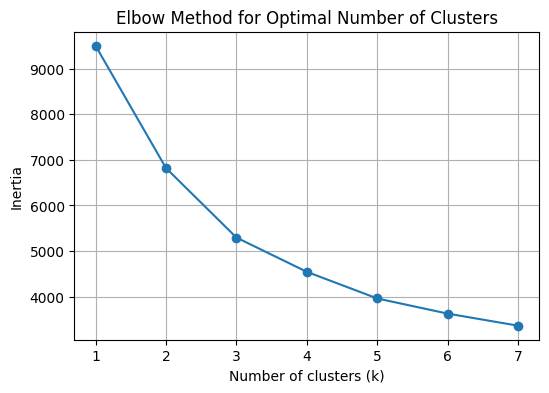

In [52]:
inertia = []
k_range = range(1, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)   # X is your final feature matrix
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [53]:
k_final = 3

kmeans = KMeans(n_clusters=k_final, random_state=42)
customers["cluster"] = kmeans.fit_predict(X)

Elbow method shows where adding more clusters does not significantly reduce inertia.

In [54]:
cluster_summary = customers.groupby("cluster")[num_features].mean().round(2)
cluster_summary

,Age,MonthlyIncome,total_spent,total_orders,total_items
cluster,,,,,
0,34.95,4442.57,331.71,3.42,12.62
1,31.26,3080.11,4347.15,19.93,74.30
2,48.86,11838.23,1102.12,8.45,31.50


In [55]:
customers["cluster"].value_counts().sort_index()

,count
cluster,
0,1011
1,94
2,375


Average spending per cluster

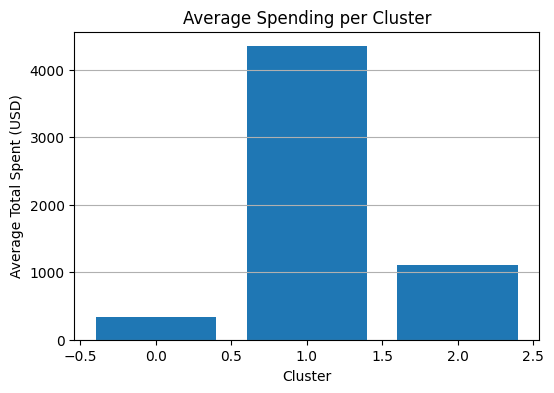

In [56]:
cluster_spend = customers.groupby("cluster")["total_spent"].mean()

plt.figure(figsize=(6,4))
plt.bar(cluster_spend.index, cluster_spend.values)
plt.title("Average Spending per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Spent (USD)")
plt.grid(axis="y")
plt.show()

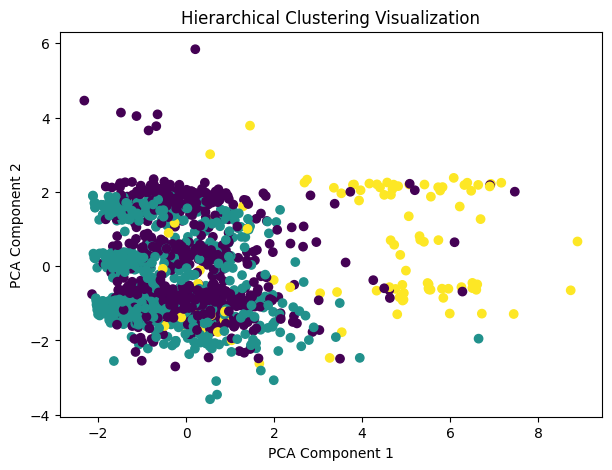

In [77]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # X — данные для кластеризации

# 2. Hierarchical clustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = hc.fit_predict(X_scaled)

# 3. PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Plot clusters
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Hierarchical Clustering Visualization")
plt.show()



###4.5.Interpret cluster profiles in a business context.

Cluster 0
Customers with low spending and few orders. These customers are price-sensitive and buy occasionally.

Cluster 1
Customers with moderate spending and stable purchasing behavior. Suitable for loyalty programs.

Cluster 2
High-value customers with high spending and many orders. Suitable for personalized offers and retention strategies.

#Task 5 Predictive Modeling: Customer Purchase Propensity

###5.1Define a binary target variable based on historical purchases

I choose one popular product category and predict whether a customer bought it or not.

In [58]:
# choose the most popular product category
target_category = transactions["item_description"].value_counts().index[0]
target_category

'Office Supplies_Paper_Staples'

In [59]:
# customers who bought the target category
buyers = transactions.loc[
    transactions["item_description"] == target_category,
    "client_id"
].unique()

# create target variable
customers["target_buy"] = customers["client_id"].isin(buyers).astype(int)

customers[["client_id", "target_buy"]].head()

,client_id,target_buy
0,C0395,0
1,C0840,0
2,C1230,0
3,C0507,0
4,C0853,0


###5.2.Aggregate transactional data to customer level only for target creation.

(In task 4 we connected two dataset with merge)

In [60]:
num_features = [
    "Age",
    "MonthlyIncome",
    "total_spent",
    "total_orders",
    "total_items"
]

cat_features = [
    "Gender",
    "MaritalStatus",
    "Department"
]

X_num = customers[num_features]
X_cat = customers[cat_features]
y = customers["target_buy"]

###5.3.Use customer attributes and generated aggregated features from transactions as model features.

Categorical variables are converted into numeric form.

In [61]:
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

Scaling improves model stability (especially for Logistic Regression).

In [62]:
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

Combine all features

In [63]:
X = np.hstack([X_num_scaled, X_cat_encoded.values])

###5.4.Train and evaluate a classification model.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

Logistic Regression is simple, interpretable, and suitable for binary prediction.

In [65]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [66]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

Evaluation metric

In [67]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.9594594594594594
Precision: 0.2222222222222222
Recall: 0.2
F1-score: 0.21052631578947367
ROC-AUC: 0.9508333333333333


ROC curve

In [68]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

Accuracy alone can be misleading, so ROC curve shows how well the model separates buyers from non-buyers.

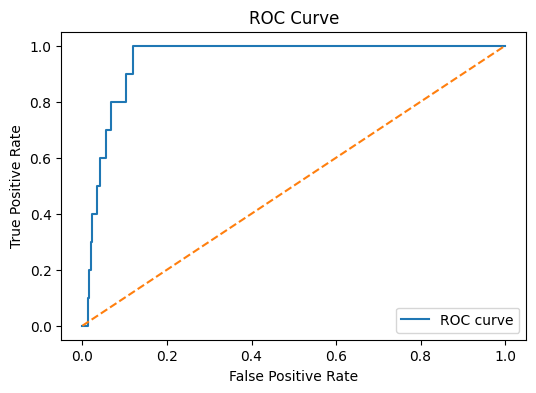

In [69]:
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()